<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
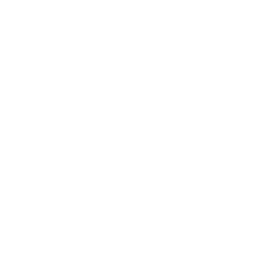
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Profilowanie ryzyka klientów za pomocą dyskryminacji kanonicznej</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Usługi finansowe / Analityka ryzyka kredytowego &nbsp;|&nbsp; Marzec 2026</p>
</div>
</div>
</div>

## Podsumowanie zarządcze

Trzy grupy statusu kredytu w portfelu hipotek konsumenckich — **z niewykonanym zobowiązaniem (defaulted)**, **bieżące (current)** oraz **spłacone przedterminowo (prepaid)** — różnią się jednocześnie wzdłuż kilku wymiarów kondycji finansowej, co sprawia, że jakikolwiek pojedynczy wskaźnik jest słabym sygnałem ryzyka. Ten notatnik stosuje **PROC CANDISC** (kanoniczną analizę dyskryminacyjną) do próby przeglądu ryzyka obejmującej 100 klientów, kondensując sześć skorelowanych wskaźników finansowych w dwa wymiary kanoniczne, które maksymalizują separację między trzema grupami statusu.

Pierwszy wymiar kanoniczny niesie niemal całą separację międzygrupową — korelacja kanoniczna **0.958**, dzieląca **91.8%** swojej wariancji z przynależnością grupową — i porządkuje kredytobiorców czytelnie od niewykonanego zobowiązania na jednym krańcu do spłaty przedterminowej na drugim. Drugi wymiar (korelacja kanoniczna **0.503**, podniesiona do kwadratu **0.254**) dodaje wtórny kontrast wiedziony historią zaległości i dźwignią finansową. Kwadraty odległości Mahalanobisa potwierdzają, że centroidy **DEFAULT** i **PREPAID** są najbardziej oddaloną parą (**75.3**), przy czym **CURRENT** znajduje się między nimi (34.3 od DEFAULT, 10.1 od PREPAID). Wynikowe wyniki kanoniczne tworzą zwarty złożony indeks ryzyka odpowiedni do segmentacji portfela i kalibracji kart scoringowych.

## Źródła danych

| Źródło | Opis | Rekordy |
|--------|-------------|--------|
| WORK.LOAN_PROFILES | Syntetyczne wskaźniki finansowe klientów i metryki behawioralne, oznaczone statusem kredytu, pobrane jako zrównoważona próba przeglądu ryzyka | 100 |

Próba celowo nadreprezentuje rachunki z niewykonanym zobowiązaniem oraz spłacone przedterminowo (pobranie w stylu case–control), tak aby każda grupa statusu była wystarczająco duża do estymacji stabilnej struktury kowariancji wewnątrzgrupowej dla analizy dyskryminacyjnej.

---

In [1]:
/* --------------------------------------------------------
   Generowanie syntetycznej próby przeglądu ryzyka kredytobiorców.
   Trzy grupy statusu (DEFAULT / CURRENT / PREPAID) są
   nadpróbkowane w kierunku ogonów ryzyka, aby każda klasa
   była dość liczna dla stabilnej wewnątrzgrupowej kowariancji.
   Wartości CLASS pozostają w ASCII — silnik formuły CANDISC
   odrzuca wartości spoza ASCII; nagłówki lokalizujemy ETYKIETĄ.
   -------------------------------------------------------- */
DANE work.loan_profiles;
    CALL streaminit(42);
    DŁUGOŚĆ loan_status $10 vintage $7 customer_id $12;
    TABLICA statuses[3] $10 _temporary_ ('DEFAULT' 'CURRENT' 'PREPAID');
    TABLICA vintages[4] $7 _temporary_ ('2022-Q1' '2022-Q3' '2023-Q1' '2023-Q3');
    POWTÓRZ i = 1 TO 20000;
        customer_id = cat('CUST-', ZAPISZ(i, z6.));
        vintage = vintages[int(rand('uniform') * 4) + 1];
        status_prob = rand('uniform');
        JEŚLI status_prob < 0.30 WTEDY status_idx = 1;       /* DEFAULT */
        PRZECIWNIE JEŚLI status_prob < 0.70 WTEDY status_idx = 2;  /* CURRENT */
        PRZECIWNIE status_idx = 3;                             /* PREPAID */
        loan_status = statuses[status_idx];
        /* Wskaźniki finansowe rozdzielają trzy grupy statusu */
        JEŚLI loan_status = 'DEFAULT' WTEDY POWTÓRZ;
            dti_ratio          = rand('normal', 0.58, 0.12);
            ltv_ratio          = rand('normal', 0.92, 0.10);
            payment_to_income  = rand('normal', 0.42, 0.08);
            credit_utilization = rand('normal', 0.85, 0.10);
            months_delinquent  = int(rand('exponential') * 4) + 1;
            savings_balance    = rand('exponential') * 4000 + 200;
        KONIEC;
        PRZECIWNIE JEŚLI loan_status = 'CURRENT' WTEDY POWTÓRZ;
            dti_ratio          = rand('normal', 0.35, 0.10);
            ltv_ratio          = rand('normal', 0.78, 0.09);
            payment_to_income  = rand('normal', 0.28, 0.07);
            credit_utilization = rand('normal', 0.45, 0.15);
            months_delinquent  = 0;
            savings_balance    = rand('exponential') * 8000 + 200;
        KONIEC;
        PRZECIWNIE POWTÓRZ;
            dti_ratio          = rand('normal', 0.22, 0.07);
            ltv_ratio          = rand('normal', 0.60, 0.12);
            payment_to_income  = rand('normal', 0.20, 0.05);
            credit_utilization = rand('normal', 0.25, 0.12);
            months_delinquent  = 0;
            savings_balance    = rand('exponential') * 16000 + 500;
        KONIEC;
        /* Zaokrąglenie i ograniczenie wskaźników do poprawnych zakresów */
        dti_ratio          = round(dti_ratio, 0.001);
        ltv_ratio          = round(ltv_ratio, 0.001);
        payment_to_income  = round(payment_to_income, 0.001);
        credit_utilization = round(credit_utilization, 0.001);
        savings_balance    = round(savings_balance, 0.01);
        JEŚLI dti_ratio < 0.05 WTEDY dti_ratio = 0.05;
        JEŚLI dti_ratio > 0.99 WTEDY dti_ratio = 0.99;
        JEŚLI ltv_ratio < 0.10 WTEDY ltv_ratio = 0.10;
        JEŚLI ltv_ratio > 1.20 WTEDY ltv_ratio = 1.20;
        JEŚLI credit_utilization < 0.01 WTEDY credit_utilization = 0.01;
        JEŚLI credit_utilization > 0.99 WTEDY credit_utilization = 0.99;
    ETYKIETA loan_status='Status kredytu'
             vintage='Rocznik'
             dti_ratio='Wskaźnik DTI (dług do dochodu)'
             ltv_ratio='Wskaźnik LTV (kredyt do wartości)'
             payment_to_income='Rata do dochodu'
             credit_utilization='Wykorzystanie kredytu'
             savings_balance='Saldo oszczędności'
             months_delinquent='Miesiące zaległości';
        WYJŚCIE;
    KONIEC;
    USUŃ i status_prob status_idx;
WYKONAJ;


NOTE: DATA work.loan_profiles

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote work.loan_profiles (100 rows, 9 columns).
NOTE: DATA elapsed:
  wall  7.25 seconds
  cpu   7.25 seconds


---

### Wyjściowe profile grup

Przed kondensacją wskaźników podsumuj, jak trzy grupy statusu różnią się zmienna po zmiennej, i potwierdź skład próby w poszczególnych rocznikach udzielenia kredytu.

                                   Rozkłady wskaźników finansowych wg statusu kredytu                                   

                                                  The MEANS Procedure

                             Analysis Variable : dti_ratio Wskaźnik DTI (dług do dochodu)

        Status kredytu          N Obs           Mean        Std Dev
        -----------------------------------------------------------
        CURRENT                    46          0.331          0.112
        DEFAULT                    29          0.570          0.114
        PREPAID                    25          0.216          0.056
        -----------------------------------------------------------

                           Analysis Variable : ltv_ratio Wskaźnik LTV (kredyt do wartości)

        Status kredytu          N Obs           Mean        Std Dev
        -----------------------------------------------------------
        CURRENT                    46          0.776          0.080
        DEF


NOTE: PROC MEANS
NOTE: PROC MEANS statement used.
NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_vintage_loan_status.spec.json
NOTE: PROC FREQ statement used.


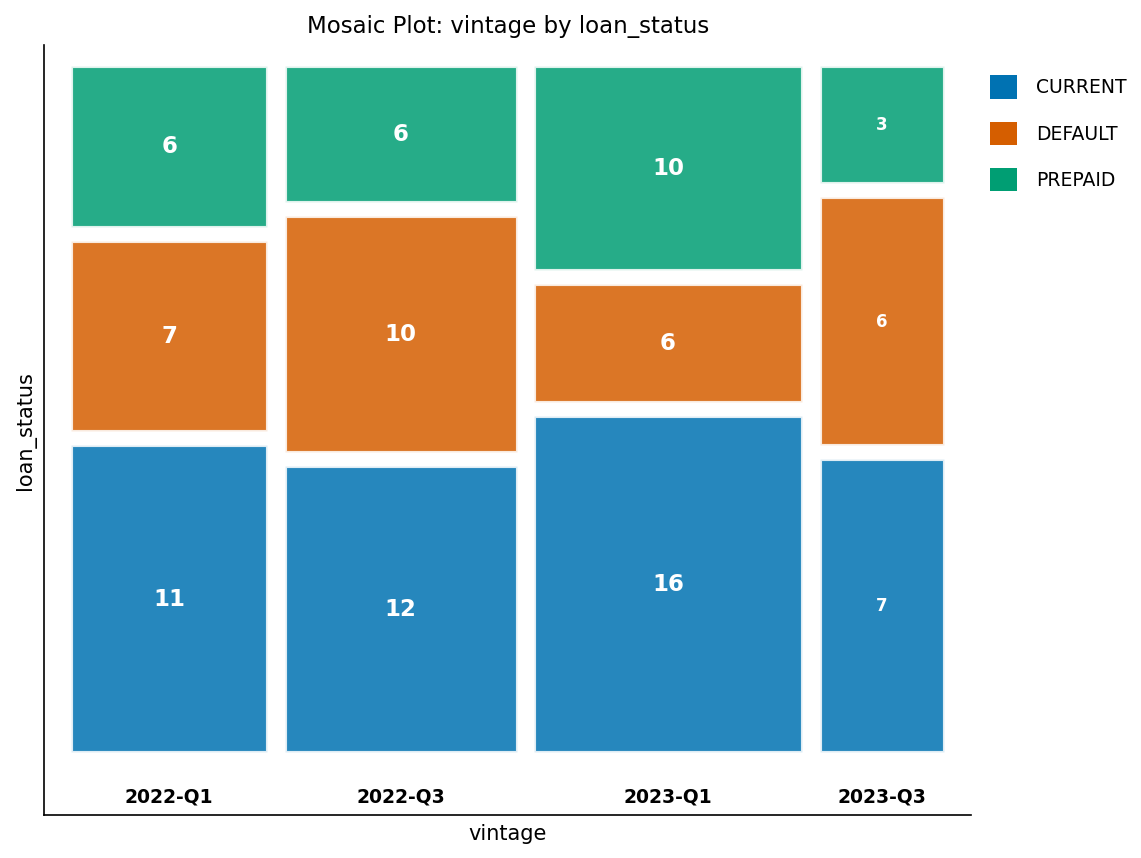

In [2]:
/* --------------------------------------------------------
   Bazowe rozkłady wskaźników finansowych wg statusu kredytu
   -------------------------------------------------------- */
PROCEDURA ŚREDNIE DANE=work.loan_profiles n mean std maxdec=3;
    KLASA loan_status;
    ZMIENNA dti_ratio ltv_ratio payment_to_income credit_utilization
        savings_balance months_delinquent;
    ETYKIETA loan_status='Status kredytu'
             vintage='Rocznik'
             dti_ratio='Wskaźnik DTI (dług do dochodu)'
             ltv_ratio='Wskaźnik LTV (kredyt do wartości)'
             payment_to_income='Rata do dochodu'
             credit_utilization='Wykorzystanie kredytu'
             savings_balance='Saldo oszczędności'
             months_delinquent='Miesiące zaległości';
    TYTUŁ 'Rozkłady wskaźników finansowych wg statusu kredytu';
WYKONAJ;

/* --------------------------------------------------------
   Skład próby wg rocznika i statusu
   -------------------------------------------------------- */
PROCEDURA CZĘSTOŚCI DANE=work.loan_profiles;
    TABLES vintage * loan_status / nocum nopercent;
    ETYKIETA loan_status='Status kredytu'
             vintage='Rocznik'
             dti_ratio='Wskaźnik DTI (dług do dochodu)'
             ltv_ratio='Wskaźnik LTV (kredyt do wartości)'
             payment_to_income='Rata do dochodu'
             credit_utilization='Wykorzystanie kredytu'
             savings_balance='Saldo oszczędności'
             months_delinquent='Miesiące zaległości';
    TYTUŁ 'Skład próby wg rocznika i statusu kredytu';
WYKONAJ;

---

### Kanoniczna analiza dyskryminacyjna

Dopasuj jeden wspólny (pooled) kanoniczny model dyskryminacyjny dla wszystkich 100 klientów. `OUT=` zapisuje wyniki kanoniczne dla poszczególnych klientów, `OUTSTAT=` przechwytuje strukturę kanoniczną, centroidy klas oraz kwadraty odległości Mahalanobisa, a `DISTANCE` żąda odległości międzygrupowych. Reklamowana tu procedura to dokładnie ta, która jest uruchamiana: **PROC CANDISC**.

                                       Skład próby wg rocznika i statusu kredytu                                        




NOTE: ODS OUTPUT: CANONICALCORRELATIONS -> can_corr
NOTE: PROC CANDISC data=work.loan_profiles ncan=Some(2) prefix=Can

NOTE: Using Python/scikit-learn for canonical discriminant analysis
NOTE: Number of Observations: 100
NOTE: Number of Classes: 3
NOTE: Class Level Information:
NOTE:   CURRENT: 46
NOTE:   DEFAULT: 29
NOTE:   PREPAID: 25
NOTE: Canonical Correlations:
NOTE:   Can1: 0.958136
NOTE:   Can2: 0.503509
NOTE: Eigenvalues of Inv(E)*H:
NOTE:                          Canonical  Approximate  Squared
NOTE:               Eigenvalue Correlation  Std Error Correlation
NOTE:   Can1       11.198645    0.958136            0.918024
NOTE:   Can2        0.339624    0.503509            0.253522
NOTE: Multivariate Statistics and F Approximations:
NOTE:   Statistic                Value     F Value  Num DF  Den DF  Pr > F
NOTE:   Wilks' Lambda         0.061194     46.65      12   184.0   0.0000
NOTE:   Pillai's Trace        1.171545     21.68      12   184.0   0.0000
NOTE:   Hotelling-Lawley  

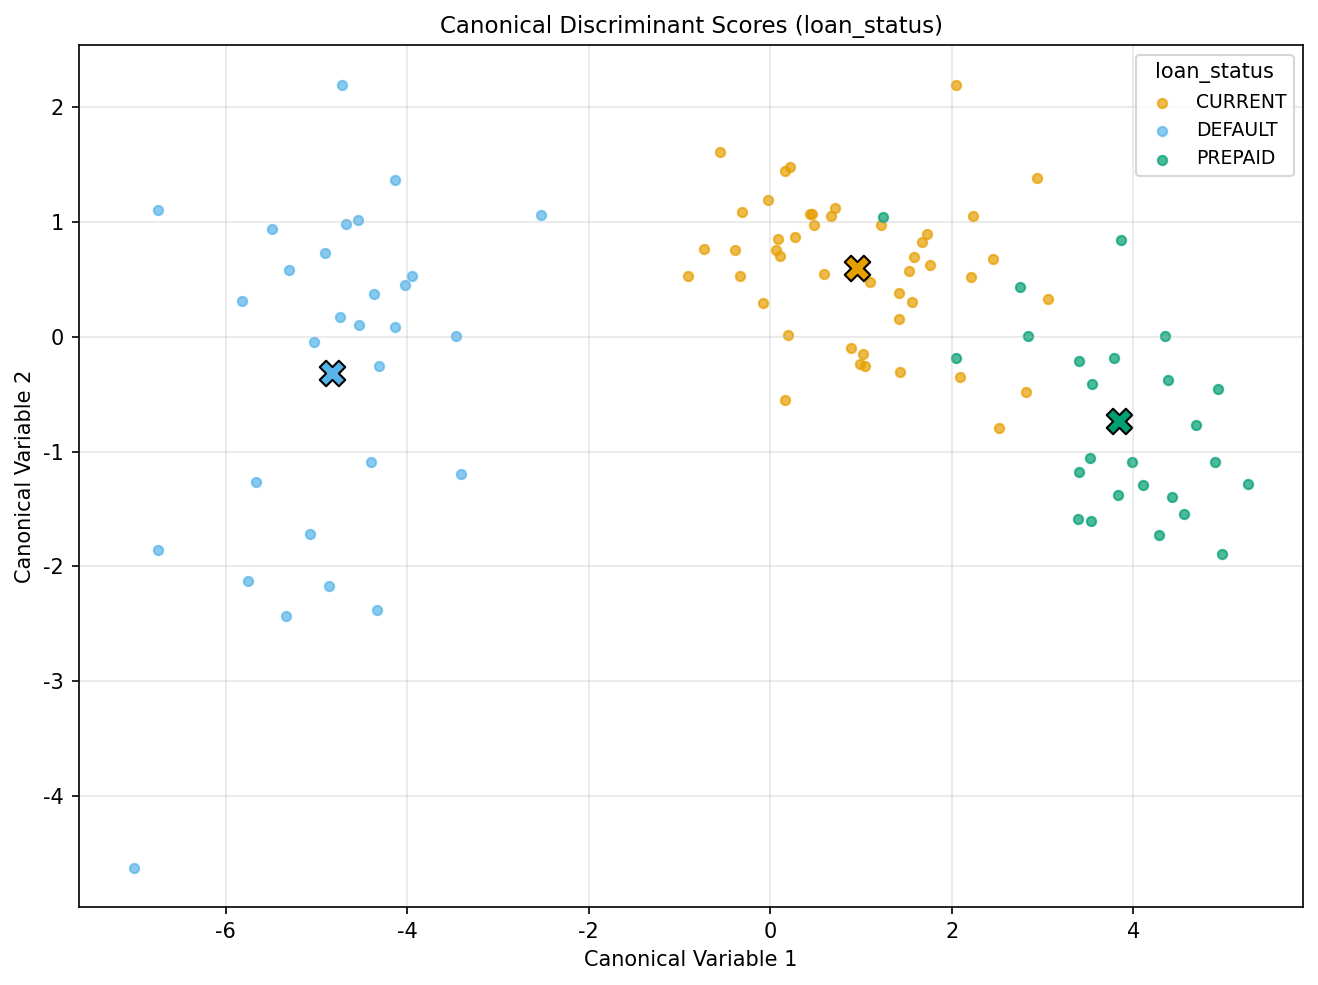

In [3]:
/* --------------------------------------------------------
   Kanoniczna analiza dyskryminacyjna grup statusu kredytu.
   OUT=    kanoniczne wyniki na klienta (Can1, Can2)
   OUTSTAT= struktura, średnie klas, odległości Mahalanobisa
   Wartości CLASS w ASCII (wymóg silnika formuły CANDISC).
   -------------------------------------------------------- */
ODS WYJŚCIE CanonicalCorrelations=work.can_corr;

PROCEDURA CANDISC DANE=work.loan_profiles
    out=work.risk_scores
    OUTSTAT=work.can_stat
    ncan=2
    distance;
    KLASA loan_status;
    ZMIENNA dti_ratio ltv_ratio payment_to_income credit_utilization
        savings_balance months_delinquent;
    ETYKIETA loan_status='Status kredytu'
             vintage='Rocznik'
             dti_ratio='Wskaźnik DTI (dług do dochodu)'
             ltv_ratio='Wskaźnik LTV (kredyt do wartości)'
             payment_to_income='Rata do dochodu'
             credit_utilization='Wykorzystanie kredytu'
             savings_balance='Saldo oszczędności'
             months_delinquent='Miesiące zaległości';
    TYTUŁ 'Kanoniczna dyskryminacja ryzyka grup statusu kredytu';
WYKONAJ;

ODS WYJŚCIE CLOSE;

---

### Korelacje kanoniczne

Jaką część separacji między trzema grupami przechwytuje każdy wymiar kanoniczny.

In [4]:
PROCEDURA DRUKUJ DANE=work.can_corr noobs label;
    TYTUŁ 'Korelacje kanoniczne';
WYKONAJ;

                                                  Korelacje kanoniczne                                                  

CANONICAL_VARIABLE  CANONICAL_CORRELATION  SQUARED_CANONICAL_CORRELATION     EIGENVALUE
Can1                         0.9581355246                   0.9180236835  11.1986452089
Can2                          0.503509317                   0.2535216323   0.3396235488




NOTE: PROC PRINT data=work.can_corr

NOTE: PROC PRINT completed: 2 observations printed, 4 variables


### Struktura kanoniczna (ładunki zmiennych)

Korelacja każdego oryginalnego wskaźnika finansowego z dwoma wymiarami kanonicznymi — na jej podstawie interpretuje się te wymiary.

In [5]:
PROCEDURA DRUKUJ DANE=work.can_stat noobs label;
    GDZIE _type_ = 'STRUCTUR';
    ZMIENNA _name_ Can1 Can2;
    ETYKIETA _name_='Zmienna' Can1='Kanoniczna 1' Can2='Kanoniczna 2';
    TYTUŁ 'Połączona wewnątrzklasowa struktura kanoniczna';
WYKONAJ;

                                     Połączona wewnątrzklasowa struktura kanoniczna                                     

           Zmienna  Kanoniczna 1  Kanoniczna 2
dti_ratio              -0.403583     -0.022755
ltv_ratio              -0.369749      0.732657
payment_to_income      -0.304192      0.117008
credit_utilization     -0.595076     -0.056264
savings_balance          0.12558      0.093182
months_delinquent      -0.323965     -0.699884




NOTE: PROC PRINT data=work.can_stat

NOTE: PROC PRINT completed: 6 observations printed, 3 variables


### Centroidy grup i odległości Mahalanobisa

Średnie klas na osiach kanonicznych (centroidy grup) oraz kwadraty odległości Mahalanobisa między każdą parą grup — podstawa kalibracji oceny ryzyka.

In [6]:
PROCEDURA DRUKUJ DANE=work.can_stat noobs label;
    GDZIE _type_ IN ('CANMEAN' 'DIST');
    ZMIENNA _type_ _name_ Can1 Can2;
    ETYKIETA _type_='Typ' _name_='Grupa' Can1='Kanoniczna 1' Can2='Kanoniczna 2';
    TYTUŁ 'Centroidy grup (CANMEAN) i kwadraty odległości Mahalanobisa (DIST)';
WYKONAJ;

                           Centroidy grup (CANMEAN) i kwadraty odległości Mahalanobisa (DIST)                           

    Typ               Grupa  Kanoniczna 1  Kanoniczna 2
CANMEAN  CURRENT                 0.956102       0.59917
CANMEAN  DEFAULT                -4.826727     -0.316237
CANMEAN  PREPAID                 3.839776     -0.735639
DIST     CURRENT to DEFAULT     34.279058             .
DIST     CURRENT to PREPAID     10.097273             .
DIST     DEFAULT to PREPAID     75.284092             .




NOTE: PROC PRINT data=work.can_stat

NOTE: PROC PRINT completed: 6 observations printed, 4 variables


---

### Mapa dyskryminacji kanonicznej

Każdy klient naniesiony w dwuwymiarowej przestrzeni kanonicznej, pokolorowany według statusu kredytu. Dobrze rozdzielone skupienia wskazują, że wyniki kanoniczne niosą silną informację o grupie.

                           Centroidy grup (CANMEAN) i kwadraty odległości Mahalanobisa (DIST)                           




NOTE: PROC SGPLOT data=work.risk_scores

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


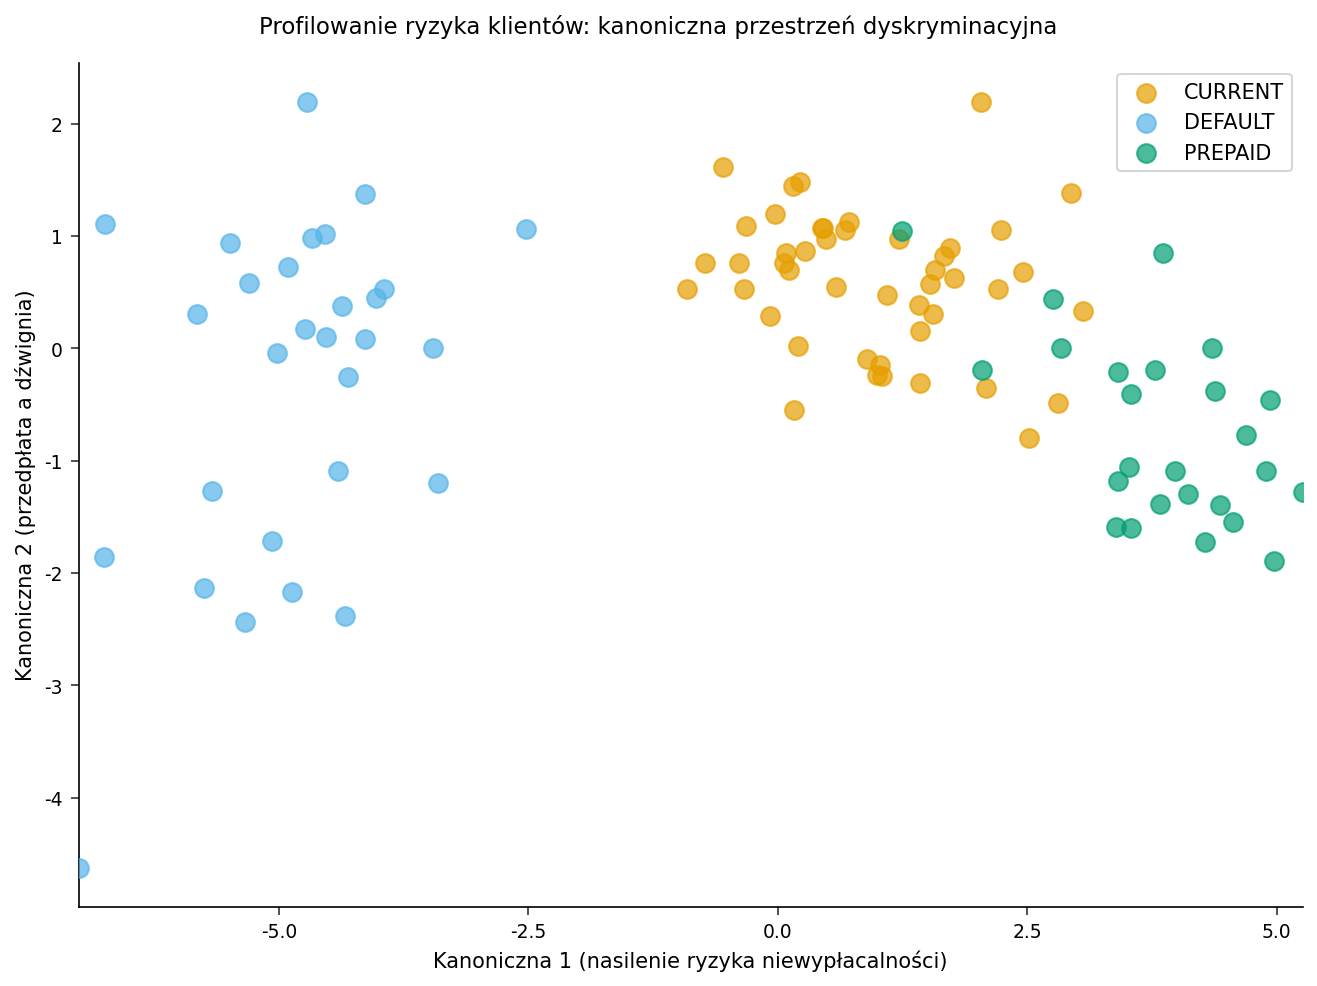

In [7]:
PROCEDURA SGPLOT DANE=work.risk_scores;
    SCATTER x=Can1 y=Can2 / GROUP=loan_status
        MARKERATTRS=(SYMBOL=circlefilled size=9)
        TRANSPARENCY=0.3;
    XAXIS ETYKIETA='Kanoniczna 1 (nasilenie ryzyka niewypłacalności)';
    YAXIS ETYKIETA='Kanoniczna 2 (przedpłata a dźwignia)';
    TYTUŁ 'Profilowanie ryzyka klientów: kanoniczna przestrzeń dyskryminacyjna';
WYKONAJ;

---

### Interpretacja

Dwa wymiary kanoniczne wyraźnie rozdzielają trzy grupy statusu kredytu w tej próbie 100 klientów (46 bieżących, 29 z niewykonanym zobowiązaniem, 25 spłaconych przedterminowo).

**Wymiar 1 — dotkliwość ryzyka niewykonania zobowiązania (korelacja kanoniczna 0.958, 91.8% wspólnej wariancji).** Ta oś sama odpowiada za przytłaczającą większość separacji grup (wartość własna 11.20 wobec 0.34 dla drugiej osi). We wspólnej wewnątrzklasowej strukturze kanonicznej ładuje się najsilniej na wykorzystanie kredytu (-0.595), wskaźnik zadłużenia do dochodu (-0.404), LTV (-0.370), miesiące zaległości (-0.324) oraz wskaźnik raty do dochodu (-0.304) — każda miara dźwigni i obciążenia wskazuje w tym samym kierunku. Ponieważ ładunki są ujemne, niskie (bardziej ujemne) wyniki Can1 oznaczają kredytobiorców o najwyższym ryzyku. Potwierdzają to centroidy klas: rachunki z niewykonanym zobowiązaniem znajdują się przy Can1 = -4.83, rachunki bieżące przy +0.96, a spłacone przedterminowo przy +3.84 — czyste monotoniczne uporządkowanie od najgorszej do najlepszej kondycji kredytowej.

**Wymiar 2 — dźwignia finansowa wobec zaległości (korelacja kanoniczna 0.503).** Druga oś przeciwstawia wskaźnik LTV (+0.733) miesiącom zaległości (-0.700): oddziela kredytobiorców silnie zadłużonych, lecz regulujących zobowiązania na bieżąco, od tych z zaległościami. Doprecyzowuje obraz w ramach Can1, lecz wnosi znacznie mniejszą separację, co pokazują niemal równe centroidy Can2 dla grup obsługujących kredyt (bieżące +0.599, spłacone przedterminowo -0.736).

**Separacja grup.** Kwadraty odległości Mahalanobisa między średnimi klas kwantyfikują luki: DEFAULT-do-PREPAID jest największa i wynosi 75.3, DEFAULT-do-CURRENT to 34.3, a CURRENT-do-PREPAID jest najmniejsza i wynosi 10.1. Dwie grupy obsługujące kredyt są zatem bliżej siebie niż którakolwiek z nich do grupy z niewykonanym zobowiązaniem, dokładnie tak, jak spodziewałby się kredytodawca.

**Zastosowanie praktyczne.** Pierwszy wynik kanoniczny zachowuje się jak gotowy złożony indeks ryzyka: kompresuje sześć skorelowanych wskaźników w jeden dobrze rozdzielony wymiar, który porządkuje klientów od najwyższego do najniższego ryzyka niewykonania zobowiązania. Zespoły portfelowe mogą segmentować według punktów odcięcia Can1, a odległości Mahalanobisa dają zasadną podstawę do przypisania nowego wnioskodawcy do najbliższej grupy statusu podczas kalibracji karty scoringowej.

---

### Eksport dla silnika scoringowego

Utrwal wyniki kanoniczne dla poszczególnych klientów oraz zbiór danych statystyk kanonicznych (który niesie centroidy i odległości Mahalanobisa) na potrzeby dalszej kalibracji karty scoringowej.

In [8]:
/* --------------------------------------------------------
   Eksport kanonicznych wyników ryzyka i statystyk kanonicznych
   -------------------------------------------------------- */
PROCEDURA EKSPORTUJ DANE=work.risk_scores
    OUTFILE='customer_risk_canonical_scores.csv'
    DBMS=csv REPLACE;
WYKONAJ;

PROCEDURA EKSPORTUJ DANE=work.can_stat
    OUTFILE='canonical_statistics.csv'
    DBMS=csv REPLACE;
WYKONAJ;


NOTE: PROC EXPORT data=work.risk_scores outfile=customer_risk_canonical_scores.csv

NOTE: Exported 100 rows to customer_risk_canonical_scores.csv.
NOTE: PROC EXPORT data=work.can_stat outfile=canonical_statistics.csv

NOTE: Exported 31 rows to canonical_statistics.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Poufne
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Utworzono przy użyciu <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>